<img src="https://github.com/GJay99/Trabajos_APS/blob/master/TS0/logo_UNSAM.jpg?raw=1" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0
#### Gonzalo Jay


# Introducción
A lo largo de este primer trabajo semanal, desarrollamos conocimientos básicos de Python y experimentamos con lo que sucede al usar distintas frecuencias para una señal senoidal, manteniendo fija la frecuencia de sampling.
Para eso, programamos una función la cual permite generar una senoidal a la cual le podemos variar la amplitud, fase, frecuencia, cantidad de puntos y frecuencia de sampleo.

\begin{equation}
x_{(t)}=A*\sin(\omega*t+\phi)+DC
\end{equation}
\begin{equation}
t_n = \frac{n}{f_s}
\end{equation}
\begin{equation}
x_{[n]}=v_{max}*\sin(2*\pi*ff*\frac{n}{f_s}+ph) + dc
\end{equation}


# Resolución
Lo primero que debemos establecer son las librerías que vamos a usar y un par de variables que nos van a ser de utilidad a la hora de definir la función.

In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np

# definiciones
fs = 1000   # Hz
N = 1000    # Muestras

Ahora escribimos la función que vamos a usar para generar nuestra función senoidal.

In [2]:
# funciones

def mi_funcion_seno(vmax = 1, dc = 0, ff = 1, ph = 0, nn = N, fs = fs):
    tt=np.zeros(nn)
    xx=np.zeros(nn)
    for n in np.arange(0,nn,1):
        tt[n]= n * (1/fs)
        xx[n]= vmax * np.sin(2*np.pi*ff * tt[n] + ph) + dc
    return tt, xx

Para comprobar que todo esté funcionando bien, probamos que se genere correctamente la senoide predeterminada.

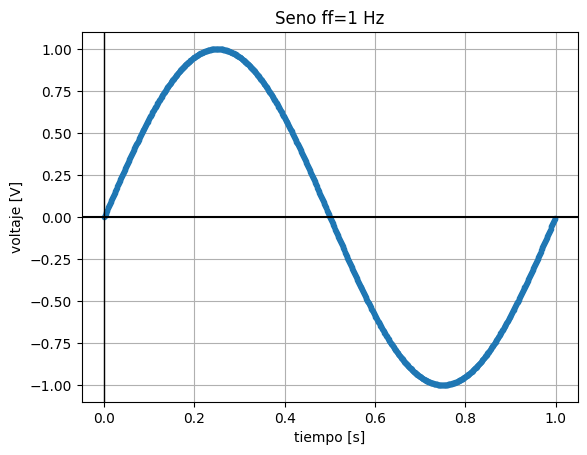

In [3]:
tt,xx = mi_funcion_seno()
plt.plot(tt, xx, linestyle=" ", marker=".")
plt.title("Seno ff=1 Hz")
plt.xlabel("tiempo [s]")
plt.ylabel("voltaje [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

## Análisis ff = 500 Hz
Una vez comprobamos que nuestra función se encuentra correctamente programada, comenzamos a analizar los casos que se nos pide en el TS0. Para eso primero vemos qué sucede si usamos ff=500 Hz.

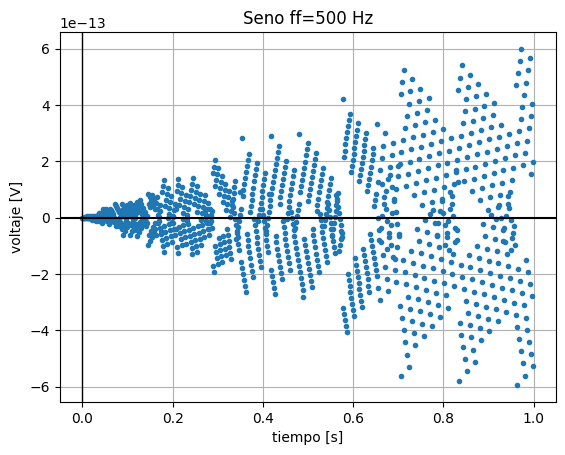

In [4]:
tt,xx = mi_funcion_seno(ff=500)
plt.plot(tt, xx, linestyle=" ", marker=".")
plt.title("Seno ff=500 Hz")
plt.xlabel("tiempo [s]")
plt.ylabel("voltaje [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

A simple vista, lo que vemos acá es un patrón bastante extraño donde a medida que aumenta el tiempo, también lo hace la amplitud, generando algo totalmente distinto a un seno. Pero, si nos fijamos bien, arriba del eje y, en x=0, podemos ver que dice 1e-13. Esto lo que nos quiere decir es que estamos en la escala $10^{-13}$, por lo cual lo que estamos viendo no es más que un montón de ceros los cuales no son exactos por el error de máquina al usar números de punto flotante como el *np.pi*.

En resumen, lo que en teoría deberíamos ver es una línea continua en el cero. Esto se debe a que usamos como frecuencia de sampleo 1000 Hz para una función seno de 500 Hz. Como vimos en clase, la frecuencia de Nyquist se puede obtener como $f_n=f_s/2$. Es decir, estamos parados exactamente sobre la frecuencia de Nyquist. Esto genera que cada vez que nuestro programa captura el valor de la senoidal lo hace justo cuando está pasando en cero, como podemos ver en la siguiente expresión matemática:
\begin{equation}
1 * \sin(2*\pi* \frac{f_s}{2} *n/f_s+0) + 0 = \sin(\pi*n) = 0,  \forall n\in \mathbb{Z}
\end{equation}

## Análisis ff = 999 Hz
Continuamos viendo qué es lo qué sucede si usamos como frecuencia 999 Hz

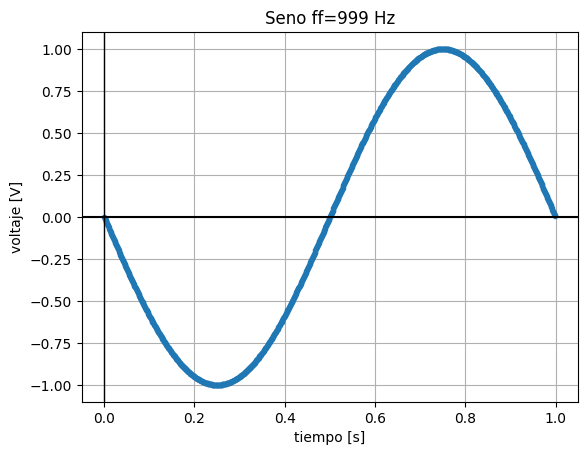

In [5]:
tt,xx = mi_funcion_seno(ff=999)
plt.plot(tt, xx, linestyle=" ", marker=".")
plt.title("Seno ff=999 Hz")
plt.xlabel("tiempo [s]")
plt.ylabel("voltaje [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Otra vez nos encontramos con un comportamiento, a simple vista, llamativo. Al usar una frecuencia de 999 Hz nos esta apareciendo exactamente lo mismo que veriamos al utilizar una frencuencia de -1 Hz. Esto se debe a que 999 Hz se encuentra a -1 Hz de la frecuencia de sampleo 1000 Hz. En el espectro de frecuencia al tomar muestras de una señal lo que terminamos generando es una periodicidad de la función en el dominio de la frecuencia. Cada $f_s$ se vuelve a repetir la respuesta en frecuencia centrada en el $f=0$, lo cual genera esta periodicidad. Si nos paramos en el $f=f_s-1$ veremos lo mismo que en el $f=2*f_s-1$ o que en el $f=0*f_s-1=-1$.

## Análisis ff=1001 Hz y ff=2001 Hz
Por último vamos a experimentar que sucede con estos dos valores de frecuencia. Según lo analizado en el caso anterior, podemos reescribir las frecuencias como $ff=1001=f_s+1$ y $ff=2001=2*f_s+1$, por lo que siguiendo el mismo razonamiento ambas señales deberían muestrearse iguales entre sí y ser exactamente iguales a la señal de frecuencia 1 Hz que usamos al inicio para verificar que nuestro programa funcione correctamente.

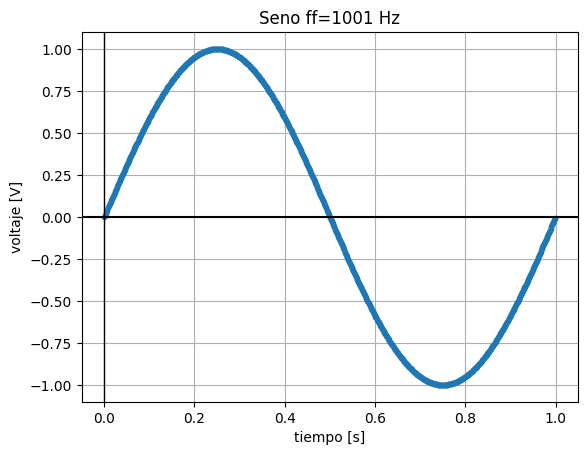

In [6]:
tt,xx = mi_funcion_seno(ff=1001)
plt.plot(tt, xx, linestyle=" ", marker=".")
plt.title("Seno ff=1001 Hz")
plt.xlabel("tiempo [s]")
plt.ylabel("voltaje [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

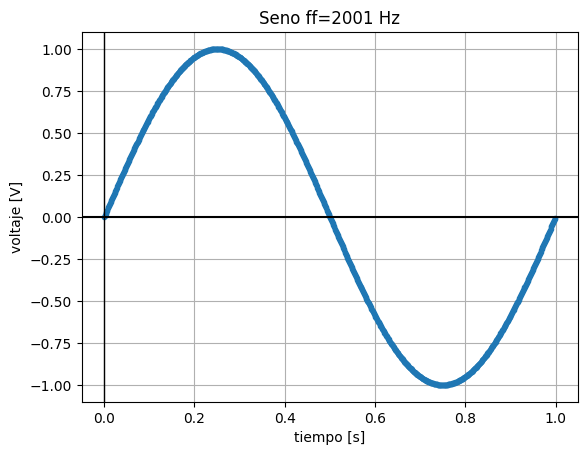

In [7]:
tt,xx = mi_funcion_seno(ff=2001)
plt.plot(tt, xx, linestyle=" ", marker=".")
plt.title("Seno ff=2001 Hz")
plt.xlabel("tiempo [s]")
plt.ylabel("voltaje [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Efectivamente, podemos apreciar que se cumple con exactitud lo que predijimos en el análisis previo. Ambas señales se comportan como una señal de 1 Hz como consecuencia de encontrarse exactamente 1 Hz por arriba de un múltiplo entero de la frecuencia de sampleo.